#Importar biblioteca de imagens

In [ ]:
!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("lokotwist/shrimp-disease-image-bd")
print("Path to dataset files:", path)

100%|██████████| 204M/204M [00:03<00:00, 65.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/lokotwist/shrimp-disease-image-bd/versions/2


#Importar bibliotecas

In [ ]:
from skimage import io, transform
from skimage.io import imread
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.datasets as datasets
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
import os
from PIL import Image

##Padronização das imagens e criação de um data_set

In [ ]:
image_path = "/root/.cache/kagglehub/datasets/lokotwist/shrimp-disease-image-bd/versions/2/Augmented_shrimp"
data = []
label = []

image_size = (128, 128)

def load_image_data(dataset_path, size=image_size):
    images = []
    labels = []

# Percorre cada subpasta (classe)
    for folder_name in os.listdir(dataset_path):
        folder_path = os.path.join(dataset_path, folder_name)
        if not os.path.isdir(folder_path):
            continue

        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            try:
                # 1. Lê a imagem
                img = cv2.imread(file_path)
                # Verifica se a imagem foi carregada corretamente
                if img is None:
                    print(f"Erro: Não foi possível carregar a imagem {file_path}")
                    continue

                # 2. Redimensiona para tamanho uniforme.
                img_resized = resize(img, size, anti_aliasing=True)

                # 3. Achatamento (Flattening) e adição aos dados
                images.append(img_resized.flatten())
                labels.append(folder_name)
            except Exception as e:
                print(f"Erro carregando {file_path}: {e}")

    return np.array(images), np.array(labels)

In [ ]:
data, labels = load_image_data(os.path.join(path, "Augmented_shrimp"))
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

print(f"Shape dos dados: {data.shape}") #número de imagens, tamanho
print(f"Shape dos rótulos: {labels_encoded.shape}") #número de imagens, número de classes
print(f"Número de classes: {len(np.unique(labels))}") #número de classes
print(f'Classes: {le.inverse_transform(np.unique(labels_encoded))}')
print(f'imagem por classe: {np.unique(labels, return_counts=True)}')


Shape dos dados: (2000, 49152)
Shape dos rótulos: (2000,)
Número de classes: 4
Classes: ['BG' 'Healthy' 'WSSV' 'WSSV_BG']
imagem por classe: (array(['BG', 'Healthy', 'WSSV', 'WSSV_BG'], dtype='<U7'), array([500, 500, 500, 500]))


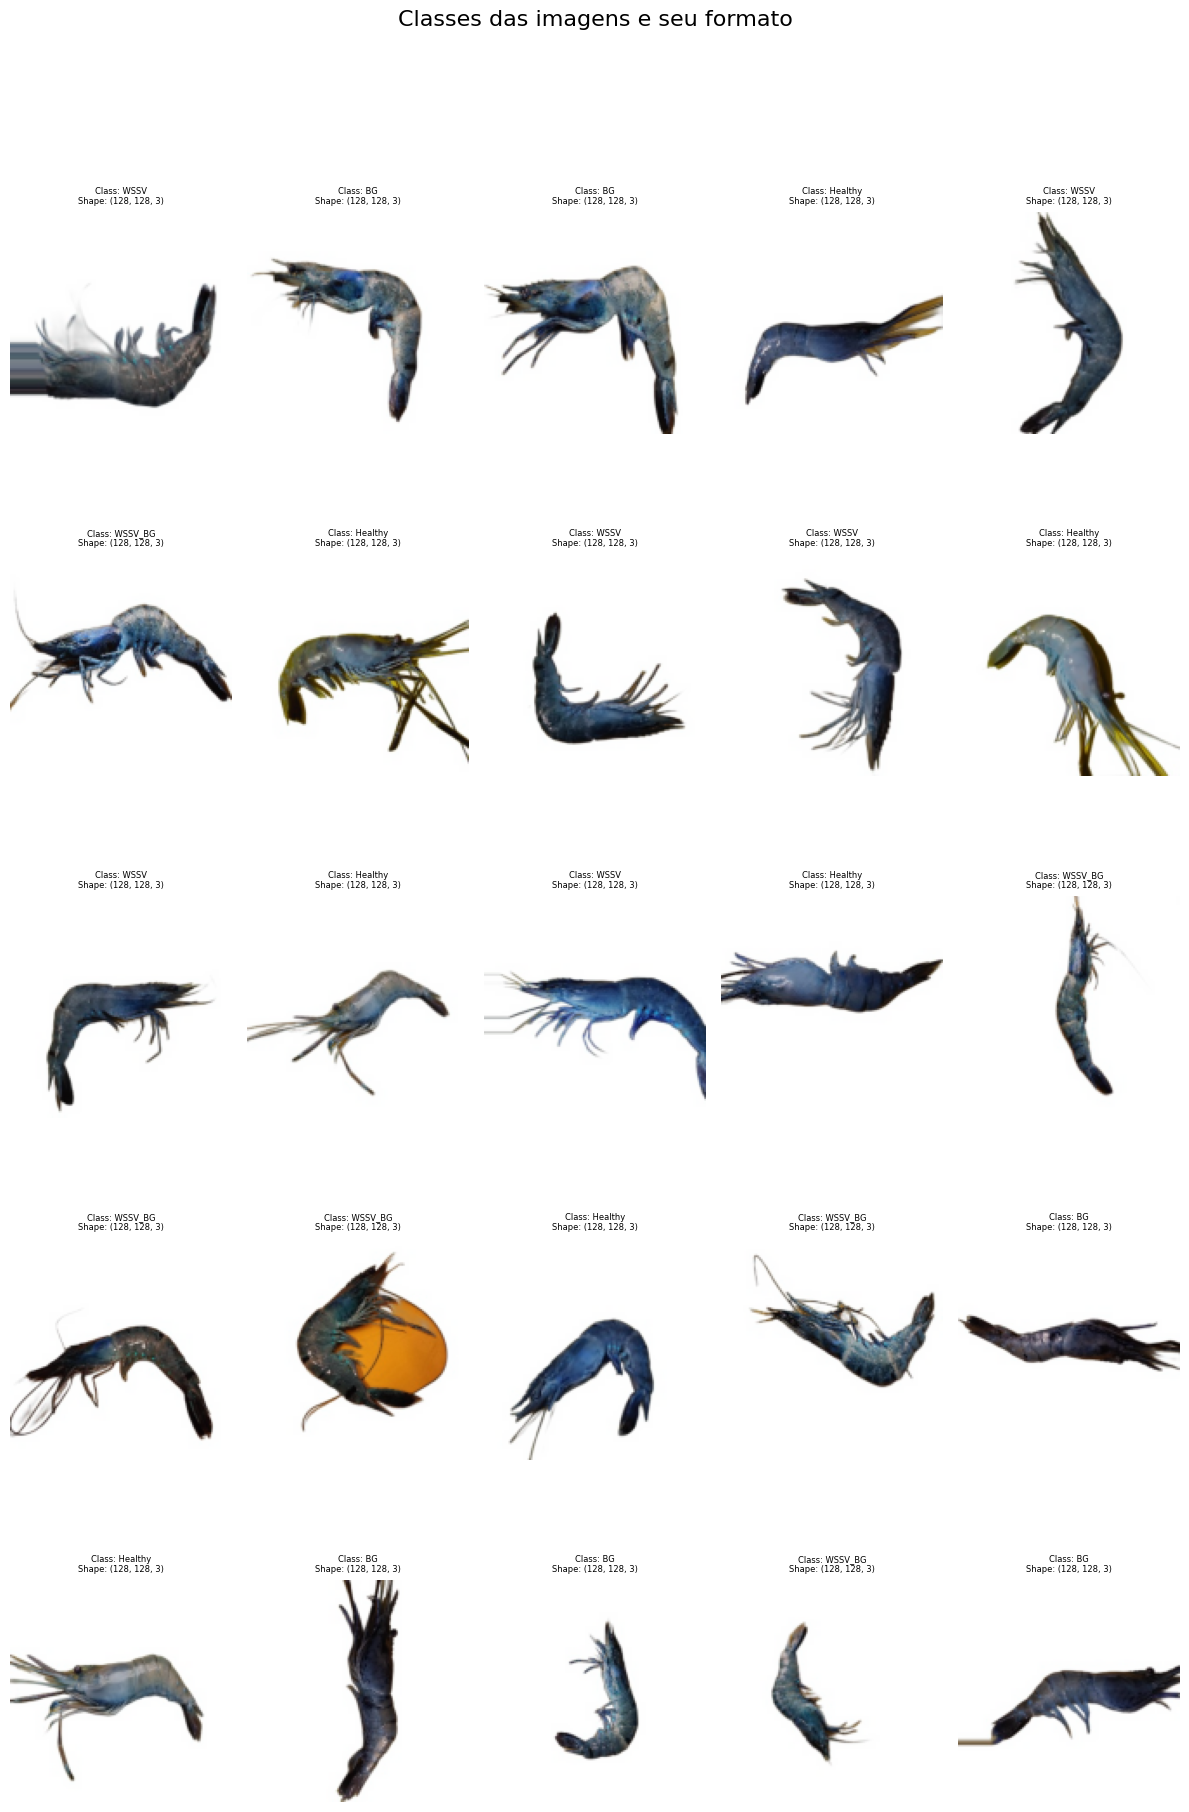

In [ ]:
#Visualização das imagens
import random

fig,ax = plt.subplots(nrows = 5, ncols = 5, figsize = (12,20)) #definiir figuras, coluna e tamanho
fig.suptitle('Classes das imagens e seu formato', fontsize=16)

# Número total de imagens a exibir
total_images_to_display = 5 * 5 # nrows * ncols

# Indicies aleatórios
random_indices = random.sample(range(len(data)), total_images_to_display)

for idx, ax_item in enumerate(ax.flatten()): # Iterate through all subplots
    current_index = random_indices[idx]

    # Imagem flattened
    flat_image = data[current_index]

    # Reshape a imagem para 128, 128 ,3
    image_to_display = flat_image.reshape(128, 128, 3)

    # Rotulando
    image_label = labels[current_index] # Usar o rotulo original

    ax_item.imshow(image_to_display)
    ax_item.set_title(f'Class: {image_label}\nShape: {image_to_display.shape}', fontsize = 6)
    ax_item.axis('off')

fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para subtitulo
fig.show()

In [ ]:
#Divisão dos dados em teste e treino
X_train, X_test, y_train, y_test = train_test_split(
    data, labels_encoded, test_size=0.2, shuffle=True
)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (1600, 49152)
Shape of y_train: (1600,)
Shape of X_test: (400, 49152)
Shape of y_test: (400,)


In [ ]:
#Escalamento das imagens para posterior análise
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##SGDClassifier

In [ ]:
from sklearn.linear_model import SGDClassifier
from time import perf_counter
sgd_clf = SGDClassifier()
start = perf_counter()
sgd_clf.fit(X_train_scaled, y_train)
end = perf_counter()
tempo_sgd = end - start
print(f"Tempo de treinamento: {end - start:.2f} segundos")

Tempo de treinamento: 18.87 segundos


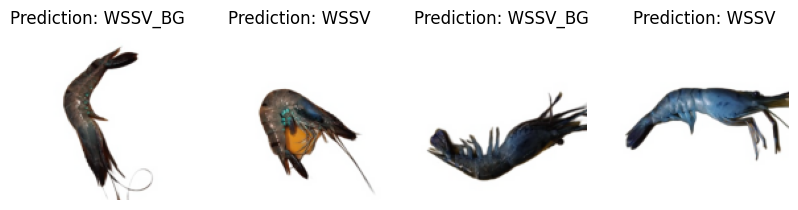

In [ ]:
# Definição da varíavel preditora
predicted = sgd_clf.predict(X_test)

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
# Display the first 4 images from X_test with their corresponding predictions
for ax, image, prediction in zip(axes, X_test[:4], predicted[:4]):
    ax.set_axis_off()
    # Reshape the flattened image back to its original dimensions (128, 128, 3)
    ax.imshow(image.reshape(128, 128, 3))
    ax.set_title(f"Prediction: {le.inverse_transform([prediction])[0]}")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3,)

Multiclass Classifier Ponderado Acuracia: 0.4094
Multiclass Classifier Ponderado Precision: 0.4184
Multiclass Classifier Ponderado Recall: 0.4206
Multiclass Classifier Ponderado F1-score: 0.4188


,BG,Healthy,WSSV,WSSV_BG
BG,197,97,60,50
Healthy,131,133,71,67
WSSV,53,73,163,116
WSSV_BG,60,50,99,180


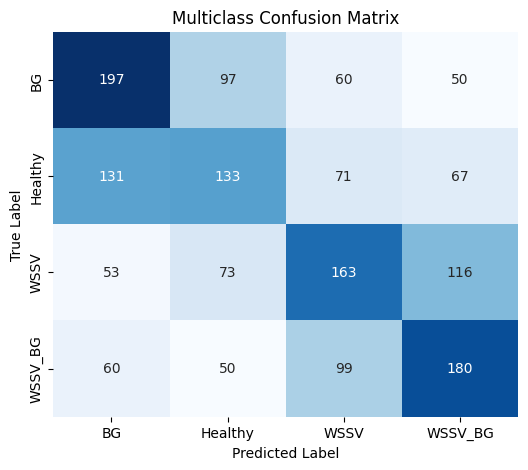

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

acuracia = cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy").mean()
precision = precision_score(y_train, y_train_pred, average='weighted')
recall = recall_score(y_train, y_train_pred, average='weighted')
f1 = f1_score(y_train, y_train_pred, average='weighted')

print(f'Multiclass Classifier Ponderado Acuracia: {acuracia:.4f}')
print(f"Multiclass Classifier Ponderado Precision: {precision:.4f}")
print(f"Multiclass Classifier Ponderado Recall: {recall:.4f}")
print(f"Multiclass Classifier Ponderado F1-score: {f1:.4f}")

conf_matrix = confusion_matrix(y_train, y_train_pred)
conf_matrix_df = pd.DataFrame(conf_matrix, index=le.classes_, columns=le.classes_)
display(conf_matrix_df)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Multiclass Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##SVMClassifier

In [ ]:
from time import perf_counter
from sklearn.svm import SVC
start = perf_counter()
svc_clf = SVC()
svc_clf.fit(X_train_scaled, y_train)
end = perf_counter()
time_svc = end - start
print(f"Tempo de treinamento: {end - start:.2f} segundos")

Tempo de treinamento: 165.02 segundos


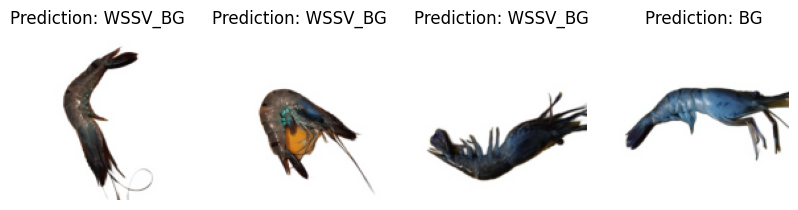

In [ ]:
# Definição da varíavel preditora
predicted = svc_clf.predict(X_test)

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
# Display the first 4 images from X_test with their corresponding predictions
for ax, image, prediction in zip(axes, X_test[:4], predicted[:4]):
    ax.set_axis_off()
    # Reshape the flattened image back to its original dimensions (128, 128, 3)
    ax.imshow(image.reshape(128, 128, 3))
    ax.set_title(f"Prediction: {le.inverse_transform([prediction])[0]}")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred_svc = cross_val_predict(svc_clf, X_train_scaled, y_train, cv=3)

Multiclass Classifier Ponderado Acuracia: 0.4544
Multiclass Classifier Ponderado Precision: 0.4525
Multiclass Classifier Ponderado Recall: 0.4544
Multiclass Classifier Ponderado F1-score: 0.4439


,BG,Healthy,WSSV,WSSV_BG
BG,204,84,46,70
Healthy,147,96,62,97
WSSV,52,26,199,128
WSSV_BG,42,20,99,228


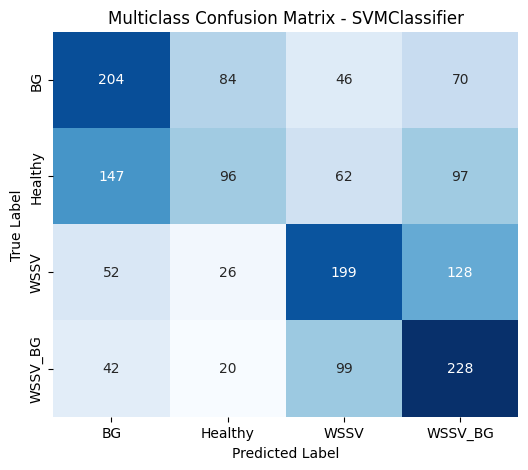

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


acuracia_svc = cross_val_score(svc_clf, X_train_scaled, y_train, cv=3, scoring="accuracy").mean()
precision_svc = precision_score(y_train, y_train_pred_svc, average='weighted')
recall_svc = recall_score(y_train, y_train_pred_svc, average='weighted')
f1_svc = f1_score(y_train, y_train_pred_svc, average='weighted')


print(f'Multiclass Classifier Ponderado Acuracia: {acuracia_svc:.4f}')
print(f"Multiclass Classifier Ponderado Precision: {precision_svc:.4f}")
print(f"Multiclass Classifier Ponderado Recall: {recall_svc:.4f}")
print(f"Multiclass Classifier Ponderado F1-score: {f1_svc:.4f}")


# Gerar e exibir a nova matriz de confusão
conf_matrix_svc = confusion_matrix(y_train, y_train_pred_svc)
conf_matrix_svc_df = pd.DataFrame(conf_matrix_svc, index=le.classes_, columns=le.classes_)
display(conf_matrix_svc_df)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_svc_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Multiclass Confusion Matrix - SVMClassifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##SVMClassifier com Kernel polinear

In [ ]:
from time import perf_counter
from sklearn.svm import SVC
svc_clf_poli = SVC(kernel = 'poly', degree = 3)
start = perf_counter()
svc_clf_poli.fit(X_train_scaled, y_train)
end = perf_counter()
tempo_svc_poli = end - start
print(f"Tempo de treinamento: {end - start:.2f} segundos")

Tempo de treinamento: 176.56 segundos


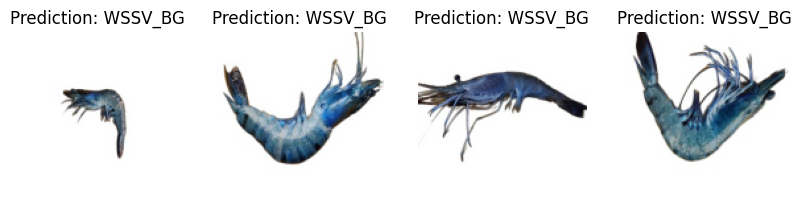

In [ ]:
# Definição da varíavel preditora
predicted_svc_poli = svc_clf_poli.predict(X_test)

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
# Display the first 4 images from X_test with their corresponding predictions
for ax, image, prediction in zip(axes, X_test[:4], predicted_svc_poli[:4]):
    ax.set_axis_off()
    # Reshape the flattened image back to its original dimensions (128, 128, 3)
    ax.imshow(image.reshape(128, 128, 3))
    ax.set_title(f"Prediction: {le.inverse_transform([prediction])[0]}")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred_svc_poli = cross_val_predict(svc_clf_poli, X_train_scaled, y_train, cv=3)

Multiclass Classifier Ponderado Acuracia: 0.3981
Multiclass Classifier Ponderado Precision: 0.4985
Multiclass Classifier Ponderado Recall: 0.3981
Multiclass Classifier Ponderado F1-score: 0.3672


,BG,Healthy,WSSV,WSSV_BG
BG,63,144,32,165
Healthy,22,123,23,234
WSSV,3,15,121,266
WSSV_BG,5,16,38,330


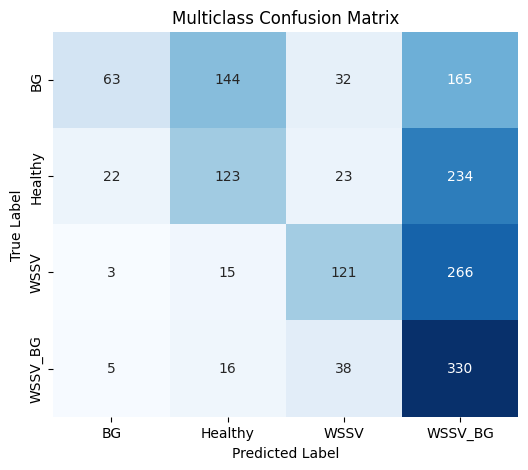

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


acuracia_svc_poli = cross_val_score(svc_clf_poli, X_train_scaled, y_train, cv=3, scoring="accuracy").mean()
precision_svc_poli = precision_score(y_train, y_train_pred_svc_poli, average='weighted')
recall_svc_poli = recall_score(y_train, y_train_pred_svc_poli, average='weighted')
f1_svc_poli = f1_score(y_train, y_train_pred_svc_poli, average='weighted')

print(f'Multiclass Classifier Ponderado Acuracia: {acuracia_svc_poli:.4f}')
print(f"Multiclass Classifier Ponderado Precision: {precision_svc_poli:.4f}")
print(f"Multiclass Classifier Ponderado Recall: {recall_svc_poli:.4f}")
print(f"Multiclass Classifier Ponderado F1-score: {f1_svc_poli:.4f}")


# Gerar e exibir a nova matriz de confusão
conf_matrix_svc_poli = confusion_matrix(y_train, y_train_pred_svc_poli)
conf_matrix_svc_poli_df = pd.DataFrame(conf_matrix_svc_poli, index=le.classes_, columns=le.classes_)
display(conf_matrix_svc_poli_df)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_svc_poli_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Multiclass Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##SVMClassifier com Kernel rbf

In [ ]:
from time import perf_counter
from sklearn.svm import SVC
svc_clf_rbf = SVC(kernel = 'rbf', degree = 3)
start = perf_counter()
svc_clf_rbf.fit(X_train_scaled, y_train)
end = perf_counter()
tempo_svc_rbf = end - start
print(f"Tempo de treinamento: {end - start:.2f} segundos")

Tempo de treinamento: 161.05 segundos


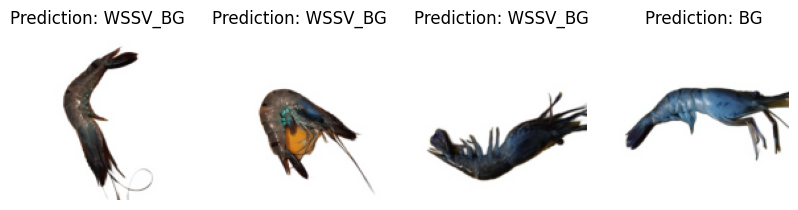

In [ ]:
# Definição da varíavel preditora
predicted_svc_rbf = svc_clf_rbf.predict(X_test)

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
# Display the first 4 images from X_test with their corresponding predictions
for ax, image, prediction in zip(axes, X_test[:4], predicted_svc_rbf[:4]):
    ax.set_axis_off()
    # Reshape the flattened image back to its original dimensions (128, 128, 3)
    ax.imshow(image.reshape(128, 128, 3))
    ax.set_title(f"Prediction: {le.inverse_transform([prediction])[0]}")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred_svc_rbf = cross_val_predict(svc_clf_rbf, X_train_scaled, y_train, cv=3)

Multiclass Classifier Ponderado Acuracia: 0.4544
Multiclass Classifier Ponderado Precision: 0.4525
Multiclass Classifier Ponderado Recall: 0.4544
Multiclass Classifier Ponderado F1-score: 0.4439


,BG,Healthy,WSSV,WSSV_BG
BG,204,84,46,70
Healthy,147,96,62,97
WSSV,52,26,199,128
WSSV_BG,42,20,99,228


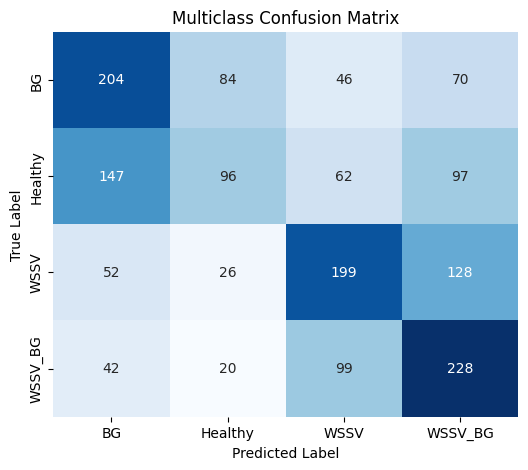

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


acuracia_svc_rbf = cross_val_score(svc_clf_rbf, X_train_scaled, y_train, cv=3, scoring="accuracy").mean()
precision_svc_rbf = precision_score(y_train, y_train_pred_svc_rbf, average='weighted')
recall_svc_rbf = recall_score(y_train, y_train_pred_svc_rbf, average='weighted')
f1_svc_rbf = f1_score(y_train, y_train_pred_svc_rbf, average='weighted')


print(f'Multiclass Classifier Ponderado Acuracia: {acuracia_svc_rbf:.4f}')
print(f"Multiclass Classifier Ponderado Precision: {precision_svc_rbf:.4f}")
print(f"Multiclass Classifier Ponderado Recall: {recall_svc_rbf:.4f}")
print(f"Multiclass Classifier Ponderado F1-score: {f1_svc_rbf:.4f}")

# Gerar e exibir a nova matriz de confusão
conf_matrix_svc_rbf = confusion_matrix(y_train, y_train_pred_svc_rbf)
conf_matrix_svc_rbf_df = pd.DataFrame(conf_matrix_svc_rbf, index=le.classes_, columns=le.classes_)
display(conf_matrix_svc_rbf_df)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_svc_rbf_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Multiclass Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from time import perf_counter
rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1)
start = perf_counter()
rnd_clf.fit(X_train_scaled, y_train)
end = perf_counter()
print(f"Tempo de treinamento: {end - start:.2f} segundos")

Tempo de treinamento: 36.66 segundos


In [ ]:
y_pred_rf = rnd_clf.predict_proba(X_test_scaled)

Multiclass Classifier Ponderado Acuracia: 0.4544
Multiclass Classifier Ponderado Precision: 0.4452
Multiclass Classifier Ponderado Recall: 0.4350
Multiclass Classifier Ponderado F1-score: 0.4299
Multiclass Classifier Ponderado ROC AUC: 0.7616


,BG,Healthy,WSSV,WSSV_BG
BG,46,17,11,22
Healthy,39,28,15,16
WSSV,10,6,41,38
WSSV_BG,17,3,32,59


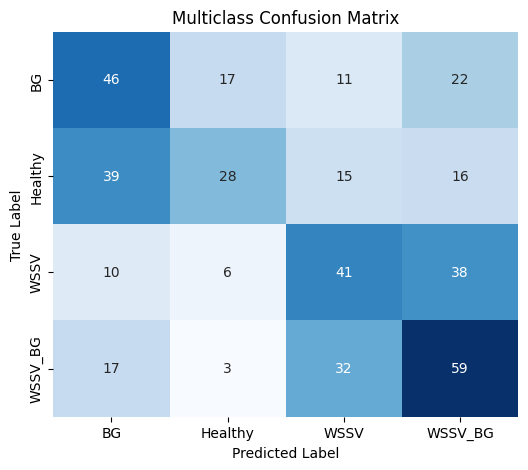

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert predicted probabilities to discrete class labels
y_pred_rf_labels = np.argmax(y_pred_rf, axis=1)

acuracia_rnd = cross_val_score(rnd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy").mean()
precision_rnd = precision_score(y_test, y_pred_rf_labels, average='weighted')
recall_rnd = recall_score(y_test, y_pred_rf_labels, average='weighted')
f1_rnd = f1_score(y_test, y_pred_rf_labels, average='weighted')
# Use predict_proba for roc_auc_score in multiclass classification
roc_auc_rnd = roc_auc_score(y_test, y_pred_rf, average='weighted', multi_class='ovr')

print(f'Multiclass Classifier Ponderado Acuracia: {acuracia_svc_rbf:.4f}')
print(f"Multiclass Classifier Ponderado Precision: {precision_rnd:.4f}")
print(f"Multiclass Classifier Ponderado Recall: {recall_rnd:.4f}")
print(f"Multiclass Classifier Ponderado F1-score: {f1_rnd:.4f}")
print(f"Multiclass Classifier Ponderado ROC AUC: {roc_auc_rnd:.4f}")

# Gerar e exibir a nova matriz de confusão
conf_matrix_rnd = confusion_matrix(y_test, y_pred_rf_labels)
conf_matrix_rnd = pd.DataFrame(conf_matrix_rnd, index=le.classes_, columns=le.classes_)
display(conf_matrix_rnd)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rnd, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Multiclass Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Métricas

In [ ]:
indices_line = ['Acurácia', 'Precisão', 'Recall', 'f1-score']
indices_comlumn = ['SGDClassifier', 'SVMClassifier', 'SVM_kernel:poli', 'SVM_kernel:rbf', 'Random Forest']
acuracia_total = [acuracia, acuracia_svc, acuracia_svc_poli, acuracia_svc_rbf, acuracia_rnd]
precisao_toal = [precision, precision_svc, precision_svc_poli, precision_svc_rbf, precision_rnd]
recall_total = [recall, recall_svc, recall_svc_poli, recall_svc_rbf, recall_rnd]
f1_total = [f1, f1_svc, f1_svc_poli, f1_svc_rbf, f1_rnd]

metricas = pd.DataFrame(
    [acuracia_total, precisao_toal, recall_total, f1_total],
    index=indices_line,
    columns=indices_comlumn
)
metricas

,SGDClassifier,SVMClassifier,SVM_kernel:poli,SVM_kernel:rbf,Random Forest
Acurácia,0.409373,0.454383,0.398141,0.454383,0.469359
Precisão,0.418407,0.452537,0.498509,0.452537,0.445245
Recall,0.420625,0.454375,0.398125,0.454375,0.435000
f1-score,0.418794,0.443942,0.367212,0.443942,0.429913


In [ ]:
indice_tempo = ['Tempo de treinamento multiclasse (s)']
tempo = [tempo_sgd, time_svc, tempo_svc_poli, tempo_svc_rbf, tempo_svc_rbf]
tempo_metricas = pd.DataFrame([tempo], index = indice_tempo, columns = indices_comlumn)
tempo_metricas

,SGDClassifier,SVMClassifier,SVM_kernel:poli,SVM_kernel:rbf,Random Forest
Tempo de treinamento multiclasse (s),18.870362,165.022197,176.56084,161.046512,161.046512


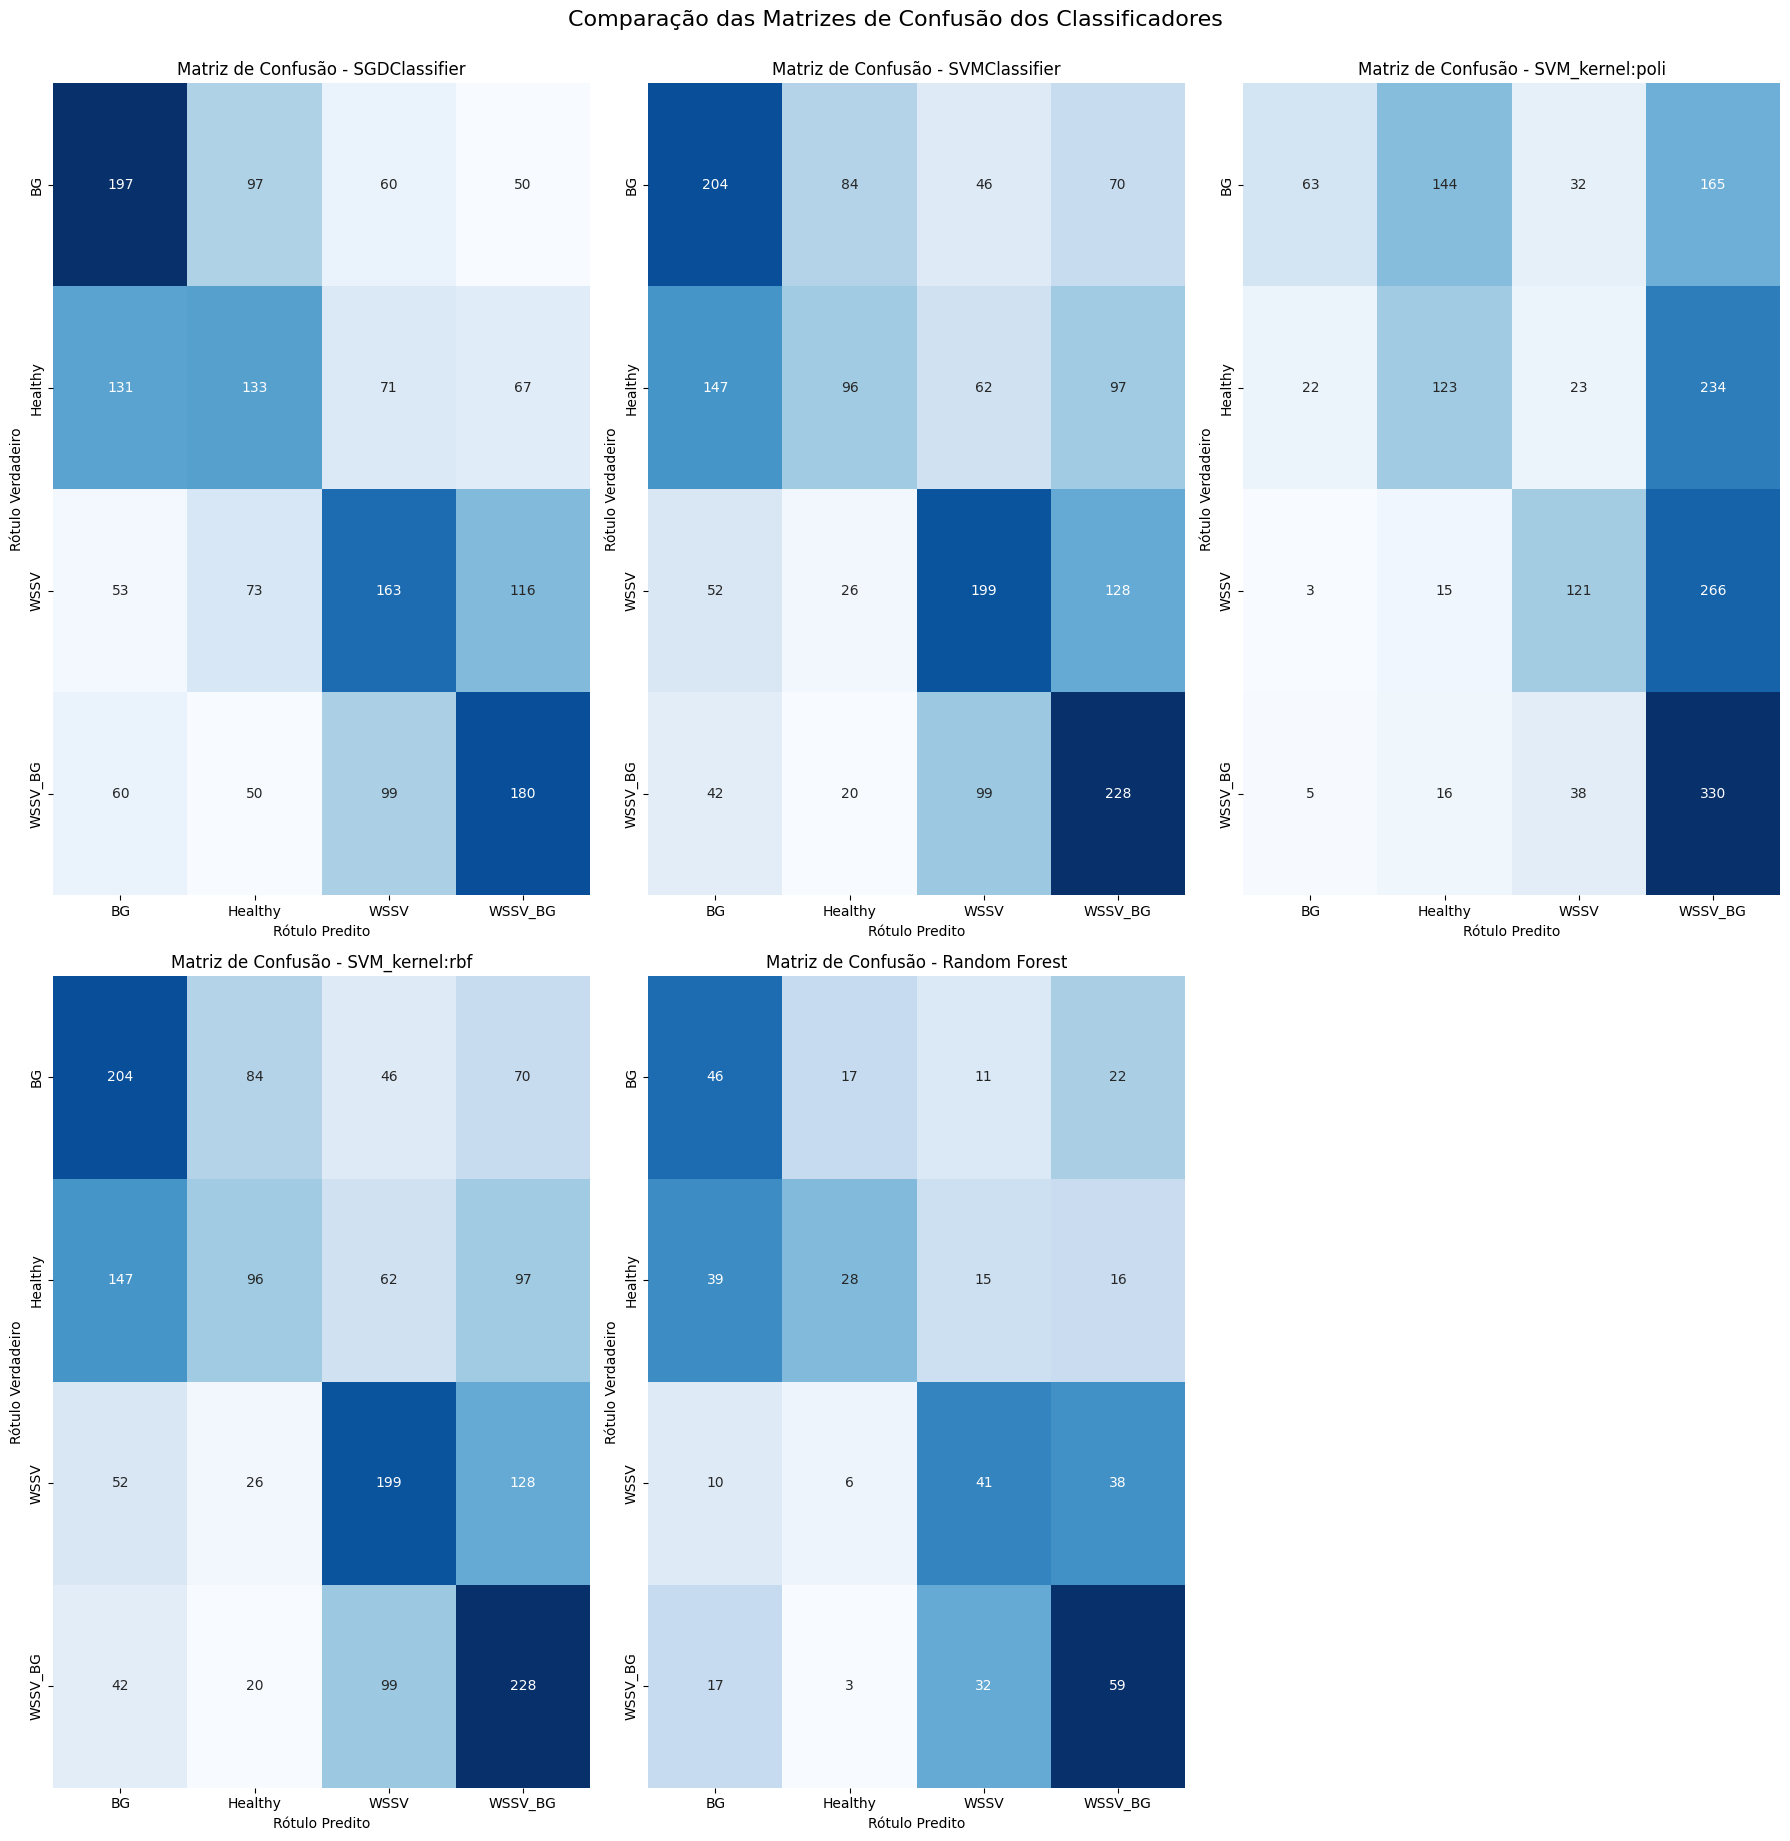

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# List of confusion matrices and their titles
confusion_matrices = {
    'SGDClassifier': conf_matrix_df,
    'SVMClassifier': conf_matrix_svc_df,
    'SVM_kernel:poli': conf_matrix_svc_poli_df,
    'SVM_kernel:rbf': conf_matrix_svc_rbf_df,
    'Random Forest': conf_matrix_rnd
}

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 18))
axes = axes.flatten()

for i, (title, matrix_df) in enumerate(confusion_matrices.items()):
    plt.sca(axes[i]) # Set the current Axes instance
    sns.heatmap(matrix_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    axes[i].set_title(f'Matriz de Confusão - {title}')
    axes[i].set_xlabel('Rótulo Predito')
    axes[i].set_ylabel('Rótulo Verdadeiro')

# Remove any unused subplots
for j in range(len(confusion_matrices), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Comparação das Matrizes de Confusão dos Classificadores', y=1.02, fontsize=16)
plt.show()